In [1]:
words = open('names.txt', 'r').read().splitlines() 

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
import torch

In [7]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [11]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [12]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

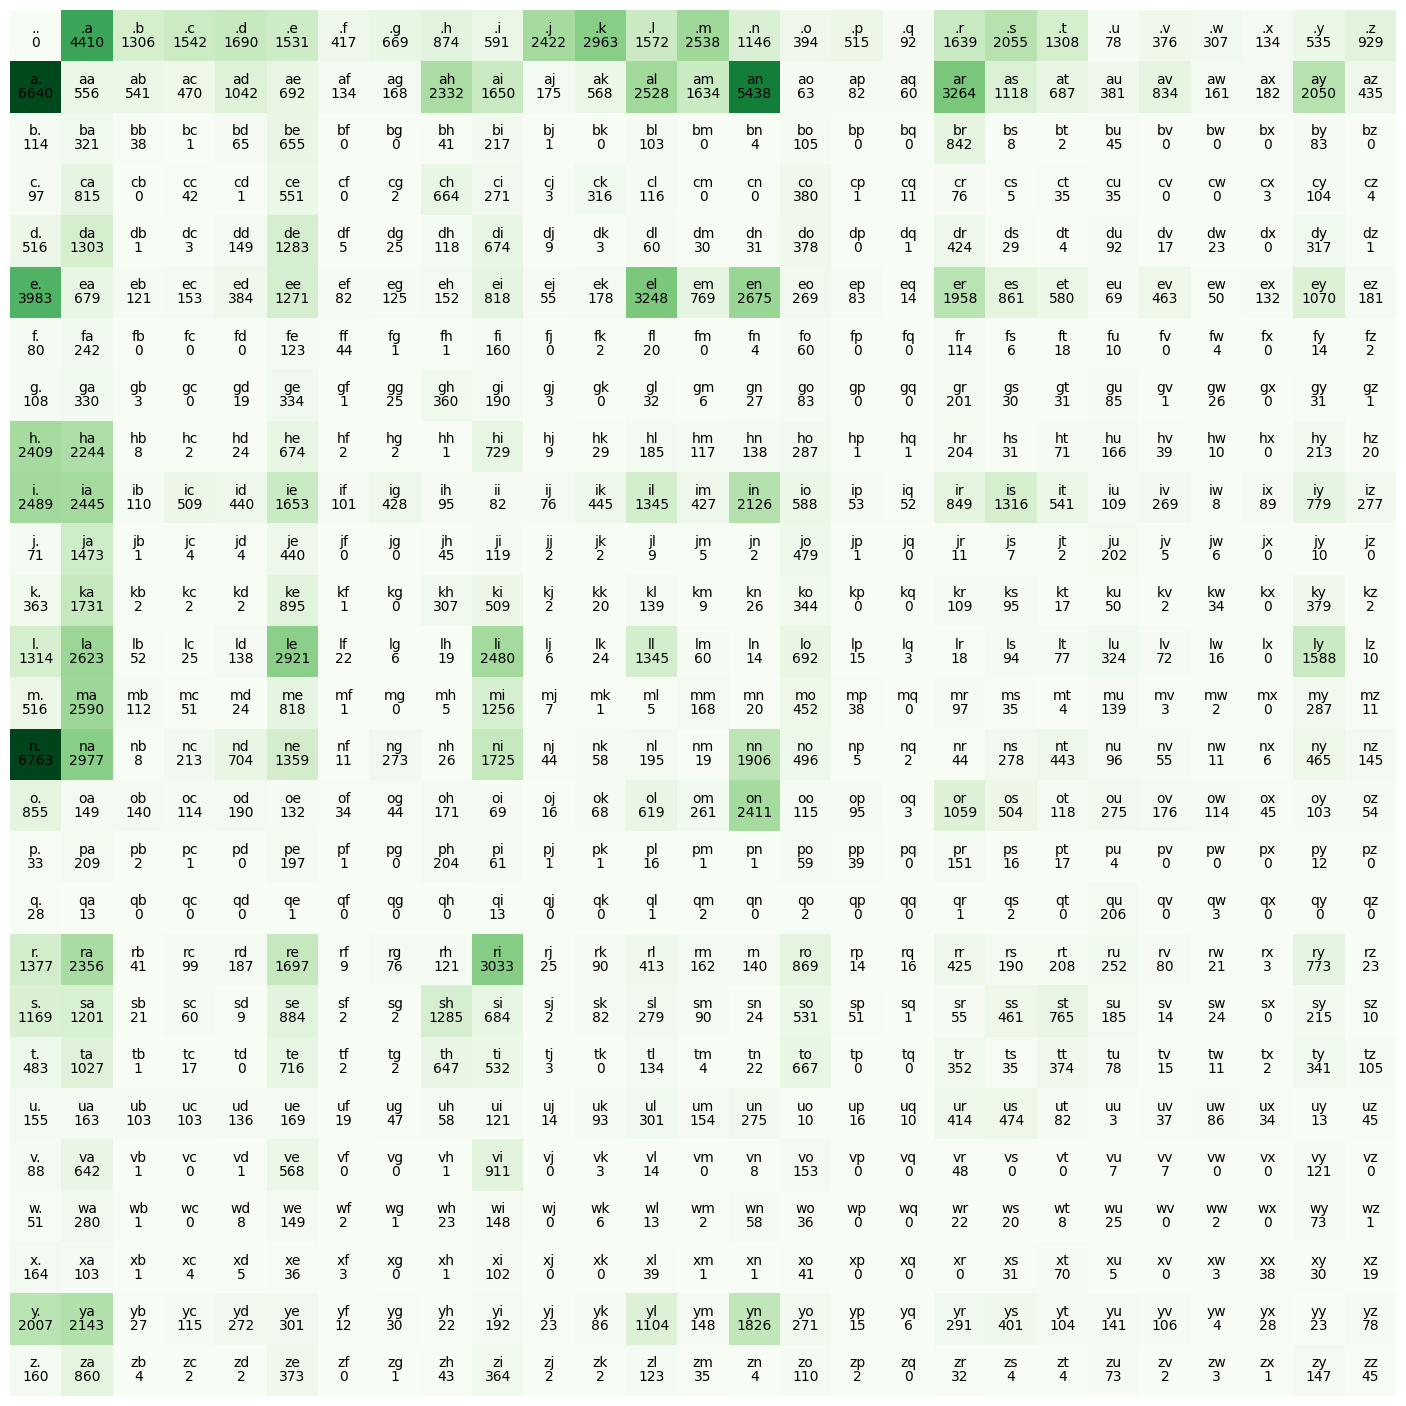

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 18))
plt.imshow(N, cmap='Greens')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='black')
plt.axis('off')

plt.show()

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = N[0].float()
p /= p.sum()

In [79]:
# Sample from p, the starting letters
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g)
ix if ix.size().numel() > 1 else itos[ix.item()]

'm'

In [62]:
ix.dim()

1

In [71]:
torch.tensor([1, 2]).size().numel()

2

In [ ]:
itos

In [55]:
set(map(itos.get, ix.tolist()))


{'a', 'b', 'c', 'd', 'e', 'i', 'j', 'k', 'l', 'm', 'o', 'r', 'v', 'z'}